# Projekt MAPB – Milestone 2: Eksploracja danych i analiza cech (Cotton Candy)

Notebook realizuje drugi kamień milowy projektu z przedmiotu **Modelowanie i analiza procesów biznesowych** dla zbioru danych *Cotton Candy* (log zdarzeń z maszyny do waty cukrowej).

## Zakres Milestone 2

1. **Przygotowanie i czyszczenie logu zdarzeń** – normalizacja timestampów, endpointów, usunięcie duplikatów
2. **Wykrywanie wartości odstających** – IQR, Isolation Forest
3. **Redukcja wymiarowości** – PCA, t-SNE, UMAP
4. **Klasteryzacja** – K-Means, DBSCAN + wizualizacje
5. **Analiza relacji między zdarzeniami** – macierz przejść (Directly-Follows), czasy przejść
6. **Wzorce czasowe** – godziny, dni tygodnia, sezonowość
7. **Analiza częstości ścieżek** – najczęstsze warianty procesu
8. **Wykrywanie anomalii** – Isolation Forest, LOF, konsensus metod

In [22]:
import os, re
from pathlib import Path
from collections import Counter, defaultdict
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score
import umap

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set(style="whitegrid")

# === ŚCIEŻKI ===
BASE_DIR = Path(r"/Users/kacperciesla/Documents/Studia/MiAPB")
DATA_DIR = BASE_DIR / "cotton-candy"

print("Katalog danych:", DATA_DIR)
print("Dostępne batche:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))

Katalog danych: /Users/kacperciesla/Documents/Studia/MiAPB/cotton-candy
Dostępne batche: ['batch-0', 'batch-1', 'batch-10', 'batch-11', 'batch-12', 'batch-13', 'batch-14', 'batch-15', 'batch-16', 'batch-17', 'batch-18', 'batch-19', 'batch-2', 'batch-20', 'batch-21', 'batch-22', 'batch-23', 'batch-3', 'batch-4', 'batch-5', 'batch-6', 'batch-7', 'batch-8', 'batch-9']


## 1. Wczytanie logu zdarzeń

Wczytujemy **wszystkie** pliki `*.xes.yaml` ze wszystkich batchy do jednego DataFrame. Wykorzystujemy szybki parser strumieniowy (z Milestone 1), który wyciąga kluczowe atrybuty:
- `case_id` – UUID instancji CPEE (`cpee:instance`), fallback na `concept:instance`
- `activity` – nazwa aktywności (`concept:name`)
- `timestamp` – czas zdarzenia (`time:timestamp`)
- `resource` – znormalizowany endpoint (`concept:endpoint`)

In [23]:
INTEREST_KEYS = {
    "concept:instance", "cpee:instance", "concept:name",
    "time:timestamp", "concept:endpoint", "id:id",
    "cpee:activity", "lifecycle:transition", "cpee:lifecycle:transition",
}

def stream_events(file_path):
    """Generator: yields (event_dict, seq_no) for each event in a .xes.yaml file."""
    current = None
    seq = 0
    with file_path.open("r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.rstrip("\n")
            if line == "---":
                if current is not None:
                    yield current, seq
                current = None
                continue
            if line == "event:":
                current = {}
                seq += 1
                continue
            if current is None:
                continue
            if line.startswith("  ") and not line.startswith("    "):
                stripped = line.strip()
                if ": " in stripped:
                    key, value = stripped.split(": ", 1)
                elif stripped.endswith(":"):
                    key, value = stripped[:-1], ""
                else:
                    continue
                if key in INTEREST_KEYS and key not in current:
                    current[key] = value.strip("'\"")
    if current is not None:
        yield current, seq

def normalize_resource(endpoint):
    """Normalizuje endpoint URL do nazwy hosta (resource proxy)."""
    if endpoint is None or pd.isna(endpoint):
        return None

    if not isinstance(endpoint, str):
        endpoint = str(endpoint)

    endpoint = endpoint.strip()
    if endpoint == "":
        return None

    endpoint = endpoint.replace("https-get://", "https://").replace("https-post://", "https://")
    parsed = urlparse(endpoint)
    return parsed.netloc if parsed.netloc else endpoint

# === Wczytanie wszystkich eventów ===
all_xes_files = sorted(DATA_DIR.glob("batch-*/*.xes.yaml"))
print(f"Liczba plików *.xes.yaml: {len(all_xes_files)}")

rows = []
for i, path in enumerate(all_xes_files, start=1):
    batch_name = path.parent.name
    file_id = str(path.relative_to(DATA_DIR)).replace("\\", "/")

    for event, seq in stream_events(path):
        rows.append({
            "batch": batch_name,
            "file": file_id,
            "case_id": event.get("cpee:instance") or event.get("concept:instance") or file_id,
            "concept_instance": event.get("concept:instance"),
            "activity": event.get("concept:name") or event.get("id:id") or event.get("cpee:activity"),
            "timestamp_raw": event.get("time:timestamp"),
            "endpoint": event.get("concept:endpoint"),
            "lifecycle": event.get("lifecycle:transition"),
            "cpee_lifecycle": event.get("cpee:lifecycle:transition"),
            "seq": seq,
        })
    if i % 200 == 0:
        print(f"  Przetworzono: {i}/{len(all_xes_files)} plików ({len(rows)} eventów)")

df = pd.DataFrame(rows)
print(f"\nWczytano {len(df)} zdarzeń z {df['case_id'].nunique()} przypadków")
print(f"Rozmiar DataFrame: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Liczba plików *.xes.yaml: 1294
  Przetworzono: 200/1294 plików (70113 eventów)
  Przetworzono: 400/1294 plików (149549 eventów)
  Przetworzono: 600/1294 plików (258503 eventów)
  Przetworzono: 800/1294 plików (347549 eventów)
  Przetworzono: 1000/1294 plików (438885 eventów)
  Przetworzono: 1200/1294 plików (526361 eventów)

Wczytano 564185 zdarzeń z 1244 przypadków
Rozmiar DataFrame: 366.7 MB


,batch,file,case_id,concept_instance,activity,timestamp_raw,endpoint,lifecycle,cpee_lifecycle,seq
0,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.602373+02:00,NaN,unknown,state/change,1
1,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.608118+02:00,NaN,unknown,endpoints/change,2
2,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.605931+02:00,NaN,unknown,dataelements/change,3
3,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.610887+02:00,NaN,unknown,attributes/change,4
4,batch-0,batch-0/028e282d-26a3-4ae8-909e-a033e6794cc8.x...,028e282d-26a3-4ae8-909e-a033e6794cc8,61168,external,2025-07-28T01:44:28.616227+02:00,NaN,unknown,description/change,5


## 2. Czyszczenie i normalizacja danych

- Parsowanie timestampów do UTC (`pd.to_datetime`)
- Normalizacja endpointów → pole `resource` (hostname)
- Oczyszczenie nazw aktywności (trimming białych znaków)
- Usunięcie duplikatów (na podstawie kluczowych kolumn)
- Usunięcie zdarzeń bez timestampa (niemożliwe do analizy czasowej)
- Sortowanie chronologiczne wewnątrz każdego case

In [24]:
# 2.1 Parsowanie timestampów do UTC
df["timestamp"] = pd.to_datetime(df["timestamp_raw"], errors="coerce", utc=True)

ts_parsed = df["timestamp"].notna().sum()
ts_total = df["timestamp_raw"].notna().sum()
print(f"Sparsowane timestampy: {ts_parsed}/{ts_total} ({ts_parsed/max(ts_total,1)*100:.1f}%)")

# 2.2 Normalizacja endpointów -> resource (hostname)
df["resource"] = df["endpoint"].apply(normalize_resource)

# 2.3 Oczyszczenie nazw aktywności
df["activity_clean"] = df["activity"].str.strip()

# 2.4 Usunięcie dokładnych duplikatów
before = len(df)
df = df.drop_duplicates(
    subset=["case_id", "activity", "timestamp_raw", "endpoint", "lifecycle", "cpee_lifecycle"]
)
after = len(df)
print(f"Usunięto duplikatów: {before - after}")

# 2.5 Sortowanie chronologiczne
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)

# 2.6 Podsumowanie braków
print(f"\nPo czyszczeniu: {len(df)} zdarzeń, {df['case_id'].nunique()} przypadków")
print(f"\nBraki danych:")
for col in ["case_id", "activity_clean", "timestamp", "resource"]:
    n_miss = df[col].isna().sum()
    print(f"  {col}: {n_miss} ({n_miss/len(df)*100:.1f}%)")

# 2.7 Usunięcie zdarzeń bez timestampa
df = df.dropna(subset=["timestamp"]).reset_index(drop=True)
print(f"\nPo usunięciu zdarzeń bez timestampa: {len(df)} zdarzeń, {df['case_id'].nunique()} cases")

# Podgląd
df[["case_id", "activity_clean", "timestamp", "resource", "batch"]].head(10)

Sparsowane timestampy: 483714/483714 (100.0%)
Usunięto duplikatów: 99812

Po czyszczeniu: 464373 zdarzeń, 1244 przypadków

Braki danych:
  case_id: 0 (0.0%)
  activity_clean: 0 (0.0%)
  timestamp: 871 (0.2%)
  resource: 115153 (24.8%)

Po usunięciu zdarzeń bez timestampa: 463502 zdarzeń, 1244 cases


,case_id,activity_clean,timestamp,resource,batch
0,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.105661+00:00,NaN,batch-6
1,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.108089+00:00,NaN,batch-6
2,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.110489+00:00,NaN,batch-6
3,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.112730+00:00,NaN,batch-6
4,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:11.121995+00:00,NaN,batch-6
5,002252ca-78eb-47cb-b28f-59fc371e4211,external,2025-08-07 12:04:12.104285+00:00,NaN,batch-6
6,002252ca-78eb-47cb-b28f-59fc371e4211,Initialize Count,2025-08-07 12:04:12.126444+00:00,NaN,batch-6
7,002252ca-78eb-47cb-b28f-59fc371e4211,Initialize Count,2025-08-07 12:04:12.127820+00:00,NaN,batch-6
8,002252ca-78eb-47cb-b28f-59fc371e4211,Move down,2025-08-07 12:04:12.174519+00:00,lab.bpm.in.tum.de,batch-6
9,002252ca-78eb-47cb-b28f-59fc371e4211,Move down,2025-08-07 12:04:16.268280+00:00,lab.bpm.in.tum.de,batch-6


## 3. Inżynieria cech i wykrywanie wartości odstających (outlierów)

Budujemy **macierz cech na poziomie przypadku** (case-level features):
- liczba zdarzeń, unikatowych aktywności, unikatowych zasobów
- czas trwania case, średni czas między zdarzeniami
- cechy temporalne (godzina startu, dzień tygodnia)
- częstości top aktywności (frequency encoding)

Następnie identyfikujemy outlierów dwoma metodami:
- **IQR** (Interquartile Range) – klasyczna metoda statystyczna
- **Isolation Forest** – algorytm uczenia maszynowego

In [25]:
# === 3.1 Macierz cech na poziomie przypadku ===

case_stats = df.groupby("case_id").agg(
    n_events=("activity_clean", "size"),
    n_unique_activities=("activity_clean", "nunique"),
    n_unique_resources=("resource", "nunique"),
    start_time=("timestamp", "min"),
    end_time=("timestamp", "max"),
    batch=("batch", "first"),
).reset_index()

# Czas trwania case [s]
case_stats["duration_sec"] = (
    case_stats["end_time"] - case_stats["start_time"]
).dt.total_seconds()

# Średni czas między zdarzeniami [s]
avg_gap = (
    df.groupby("case_id")["timestamp"]
    .apply(lambda x: x.diff().dt.total_seconds().mean() if len(x) > 1 else 0)
    .rename("avg_gap_sec")
)
case_stats = case_stats.merge(avg_gap, on="case_id", how="left")
case_stats["avg_gap_sec"] = case_stats["avg_gap_sec"].fillna(0)

# Cechy temporalne
case_stats["start_hour"] = case_stats["start_time"].dt.hour
case_stats["start_dow"] = case_stats["start_time"].dt.dayofweek  # 0=Mon, 6=Sun

# Frequency encoding: top 15 aktywności jako osobne kolumny
# Uwaga: skracanie nazw może powodować kolizje, więc pilnujemy unikalności nazw kolumn.
top_activities = df["activity_clean"].value_counts().head(15).index.tolist()
used_feature_names = set(case_stats.columns)

for i, act in enumerate(top_activities, start=1):
    base_name = re.sub(r"[^a-zA-Z0-9]", "_", str(act)).strip("_")
    if not base_name:
        base_name = f"activity_{i}"

    # Dodajemy indeks pozycji, aby uniknąć kolizji po obcięciu długości nazwy.
    col_name = f"act_{i:02d}_{base_name[:24]}"

    # Dodatkowe zabezpieczenie na wypadek rzadkich kolizji.
    suffix = 1
    unique_name = col_name
    while unique_name in used_feature_names:
        suffix += 1
        unique_name = f"{col_name}_{suffix}"
    col_name = unique_name
    used_feature_names.add(col_name)

    act_counts = (
        df[df["activity_clean"] == act]
        .groupby("case_id")
        .size()
        .rename(col_name)
    )

    case_stats = case_stats.merge(act_counts, on="case_id", how="left")
    case_stats[col_name] = case_stats[col_name].fillna(0).astype(int)

print(f"Macierz cech: {case_stats.shape[0]} cases × {case_stats.shape[1]} kolumn")
print(f"\nStatystyki kluczowych cech:")
print(case_stats[["n_events", "n_unique_activities", "duration_sec", "avg_gap_sec"]].describe())

# === 3.2 Standaryzacja cech numerycznych ===
numeric_cols = ["n_events", "duration_sec", "n_unique_activities", "avg_gap_sec", "n_unique_resources"]
feature_cols = numeric_cols + [c for c in case_stats.columns if c.startswith("act_")]
X_features = case_stats[feature_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
print(f"\nZeskalowana macierz cech: {X_scaled.shape}")

Macierz cech: 1244 cases × 26 kolumn

Statystyki kluczowych cech:
           n_events  n_unique_activities   duration_sec  avg_gap_sec
count   1244.000000          1244.000000    1244.000000  1244.000000
mean     372.590032             8.031350     385.362545     2.550818
std     1158.427617             7.399407    5923.378721    35.636584
min       15.000000             4.000000       3.726642     0.162403
25%       27.000000             4.000000      19.465343     0.349526
50%       42.000000             5.000000      32.381377     0.506104
75%       81.000000             7.000000      83.757225     1.047164
max    26192.000000            34.000000  205121.405661  1235.671118

Zeskalowana macierz cech: (1244, 20)


Outliery (IQR): 304 / 1244 (24.4%)
  n_events: 194 outlierów
  duration_sec: 213 outlierów
  n_unique_activities: 184 outlierów
  avg_gap_sec: 119 outlierów

Outliery (Isolation Forest, 5%): 63 / 1244


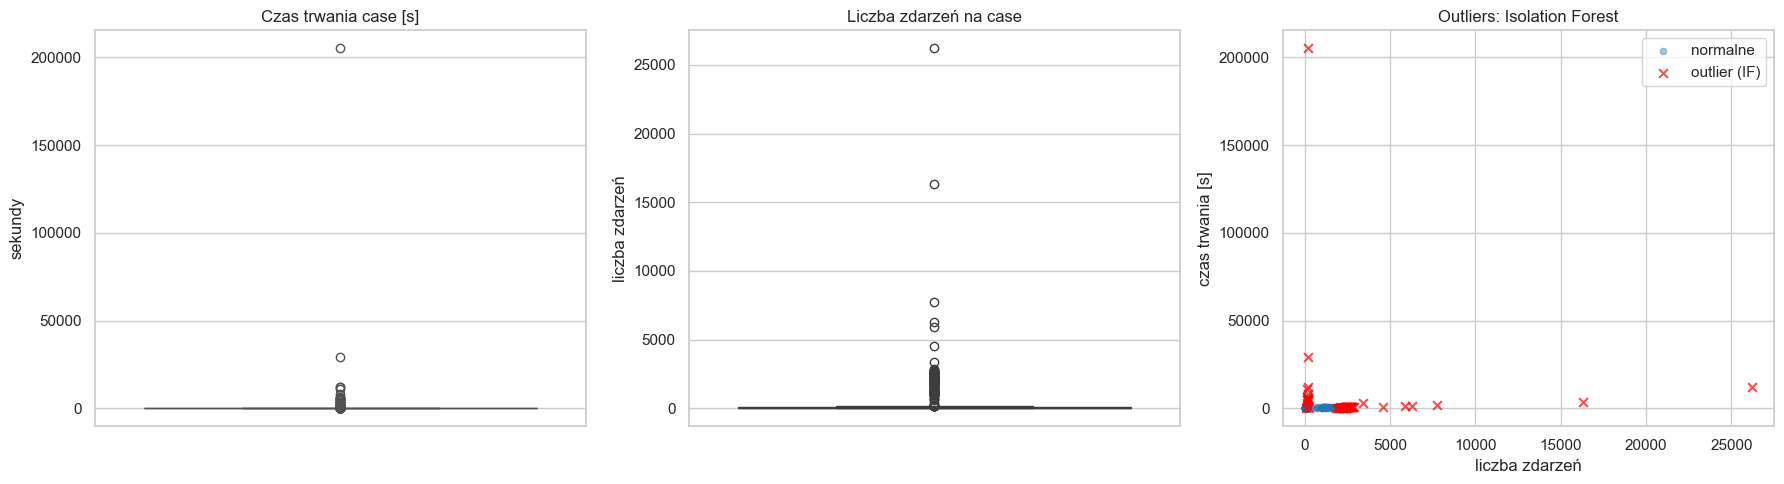


Outliery wspólne (IQR ∩ IF): 62


In [26]:
# === 3.3 Wykrywanie outlierów ===

# --- Metoda IQR ---
iqr_flags = pd.DataFrame(index=case_stats.index)
for col in numeric_cols:
    Q1 = case_stats[col].quantile(0.25)
    Q3 = case_stats[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_flags[col] = (case_stats[col] < Q1 - 1.5 * IQR) | (case_stats[col] > Q3 + 1.5 * IQR)

case_stats["iqr_outlier"] = iqr_flags.any(axis=1)
print(f"Outliery (IQR): {case_stats['iqr_outlier'].sum()} / {len(case_stats)} "
      f"({case_stats['iqr_outlier'].mean()*100:.1f}%)")

# Szczegóły: ile outlierów per cecha
for col in numeric_cols:
    n = iqr_flags[col].sum()
    if n > 0:
        print(f"  {col}: {n} outlierów")

# --- Isolation Forest ---
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
case_stats["iso_outlier"] = iso_forest.fit_predict(X_scaled) == -1
print(f"\nOutliery (Isolation Forest, 5%): {case_stats['iso_outlier'].sum()} / {len(case_stats)}")

# === 3.4 Wizualizacja outlierów ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=case_stats["duration_sec"], ax=axes[0], color="#ff7f0e")
axes[0].set_title("Czas trwania case [s]")
axes[0].set_ylabel("sekundy")

sns.boxplot(y=case_stats["n_events"], ax=axes[1], color="#2ca02c")
axes[1].set_title("Liczba zdarzeń na case")
axes[1].set_ylabel("liczba zdarzeń")

# Scatter z oznaczeniem outlierów Isolation Forest
normal_mask = ~case_stats["iso_outlier"]
axes[2].scatter(
    case_stats.loc[normal_mask, "n_events"],
    case_stats.loc[normal_mask, "duration_sec"],
    alpha=0.4, s=20, label="normalne", c="#1f77b4"
)
axes[2].scatter(
    case_stats.loc[~normal_mask, "n_events"],
    case_stats.loc[~normal_mask, "duration_sec"],
    alpha=0.7, s=40, label="outlier (IF)", c="red", marker="x"
)
axes[2].set_xlabel("liczba zdarzeń")
axes[2].set_ylabel("czas trwania [s]")
axes[2].set_title("Outliers: Isolation Forest")
axes[2].legend()

plt.tight_layout()
plt.show()

# Wspólne outliery obu metod
both = (case_stats["iqr_outlier"] & case_stats["iso_outlier"]).sum()
print(f"\nOutliery wspólne (IQR ∩ IF): {both}")

## 4. Redukcja wymiarowości (PCA / t-SNE / UMAP)

Stosujemy trzy metody redukcji wymiarowości na macierzy cech case-level:
- **PCA** – liniowa redukcja, analiza wariancji wyjaśnionej
- **t-SNE** – nieliniowa, dobra do wizualizacji lokalnych struktur
- **UMAP** – nieliniowa, zachowuje strukturę globalną i lokalną

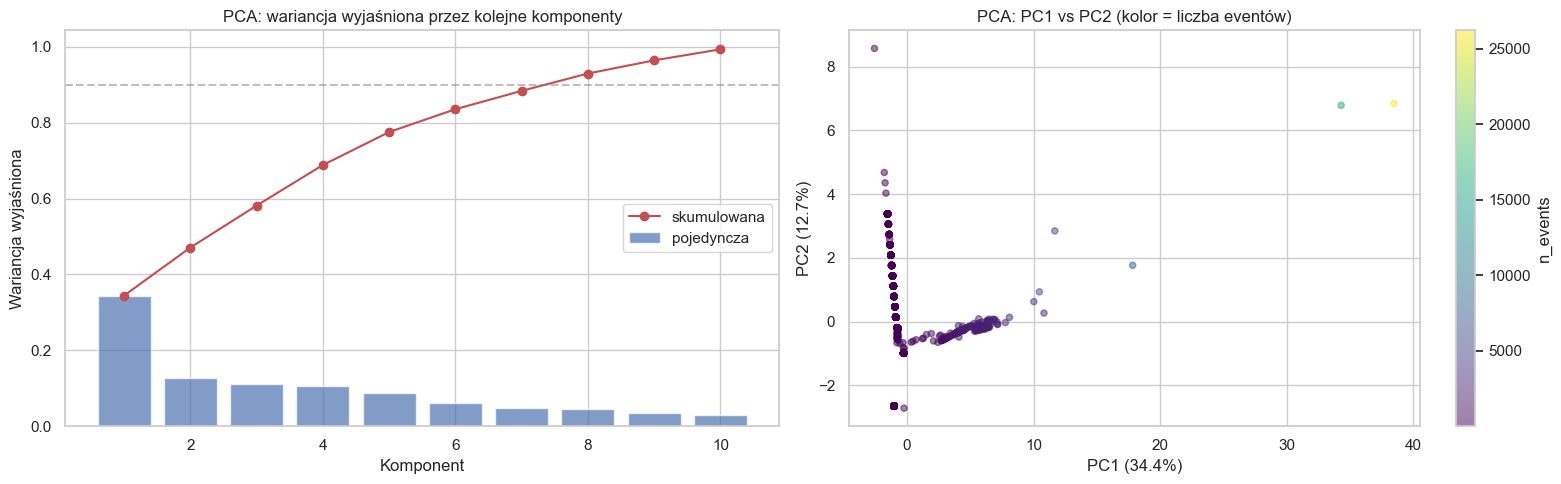

Komponenty potrzebne do 90% wariancji: 8
Wariancja PC1+PC2: 47.1%


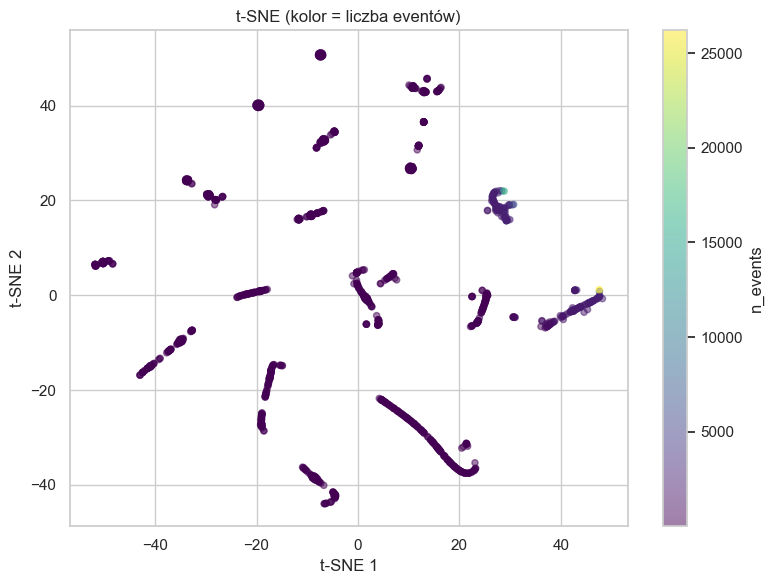

/opt/miniconda3/envs/base1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


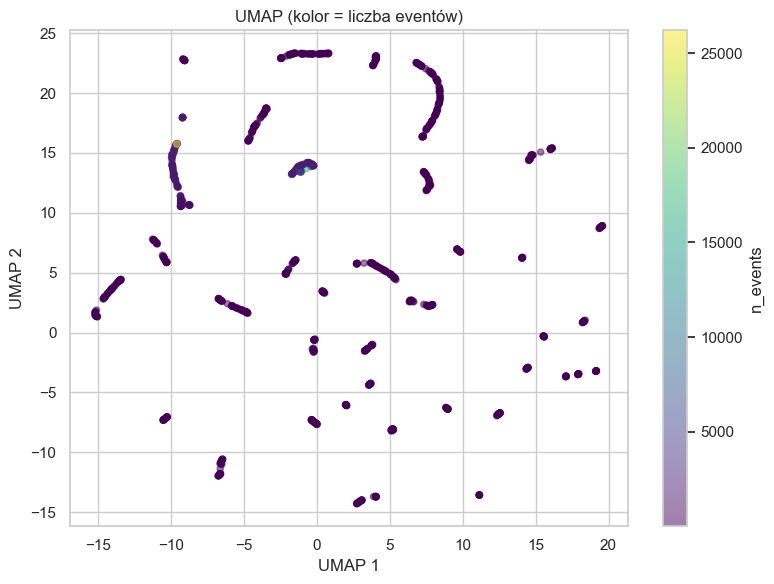

In [27]:
# === 4.1 PCA ===
n_components_pca = min(10, X_scaled.shape[1])
pca = PCA(n_components=n_components_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Wariancja wyjaśniona
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, alpha=0.7, label="pojedyncza")
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'ro-', label="skumulowana")
axes[0].set_xlabel("Komponent")
axes[0].set_ylabel("Wariancja wyjaśniona")
axes[0].set_title("PCA: wariancja wyjaśniona przez kolejne komponenty")
axes[0].legend()
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label="90%")

# Scatter PC1 vs PC2
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=case_stats["n_events"], cmap="viridis", alpha=0.5, s=20)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA: PC1 vs PC2 (kolor = liczba eventów)")
plt.colorbar(sc, ax=axes[1], label="n_events")

plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cumvar >= 0.9)) + 1
print(f"Komponenty potrzebne do 90% wariancji: {n_90}")
print(f"Wariancja PC1+PC2: {cumvar[1]*100:.1f}%")

# === 4.2 t-SNE ===
perplexity = min(30, max(5, len(X_scaled) // 5))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                 c=case_stats["n_events"], cmap="viridis", alpha=0.5, s=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (kolor = liczba eventów)")
plt.colorbar(sc, label="n_events")
plt.tight_layout()
plt.show()

# === 4.3 UMAP ===
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1],
                 c=case_stats["n_events"], cmap="viridis", alpha=0.5, s=20)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP (kolor = liczba eventów)")
plt.colorbar(sc, label="n_events")
plt.tight_layout()
plt.show()

## 5. Klasteryzacja

Stosujemy dwa algorytmy klasteryzacji na zestandaryzowanej macierzy cech:
- **K-Means** – z doborem optymalnego *k* (Elbow + Silhouette)
- **DBSCAN** – wykrywanie klastrów o dowolnym kształcie + identyfikacja szumu

Wyniki wizualizujemy na rzutach UMAP.

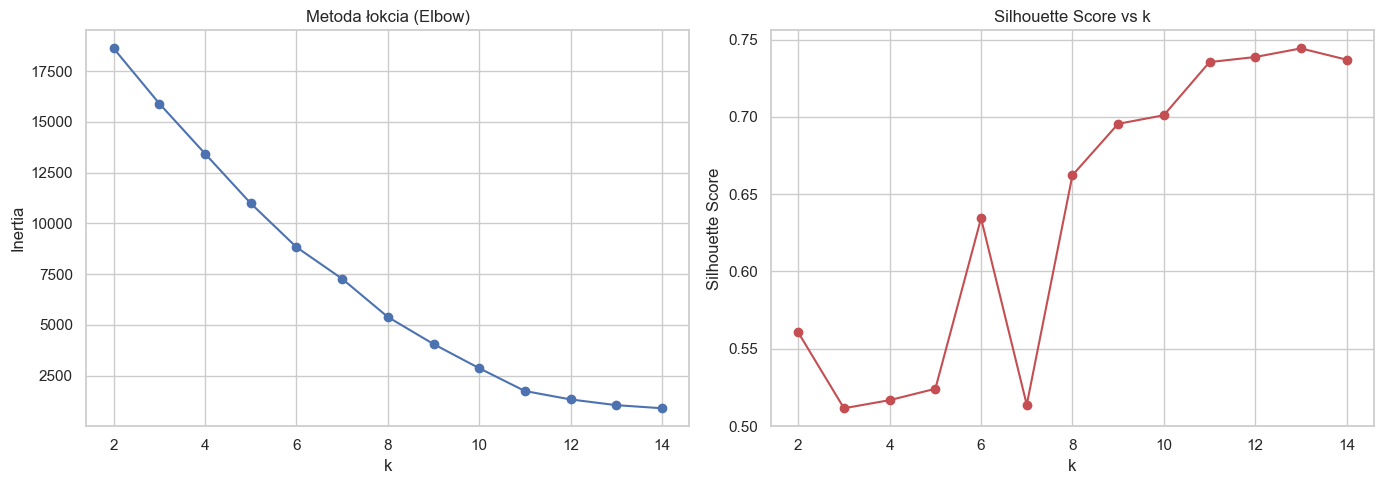

Najlepsze k (max silhouette): 13 (score=0.744)
DBSCAN: 8 klastrów, 21 punktów szumu


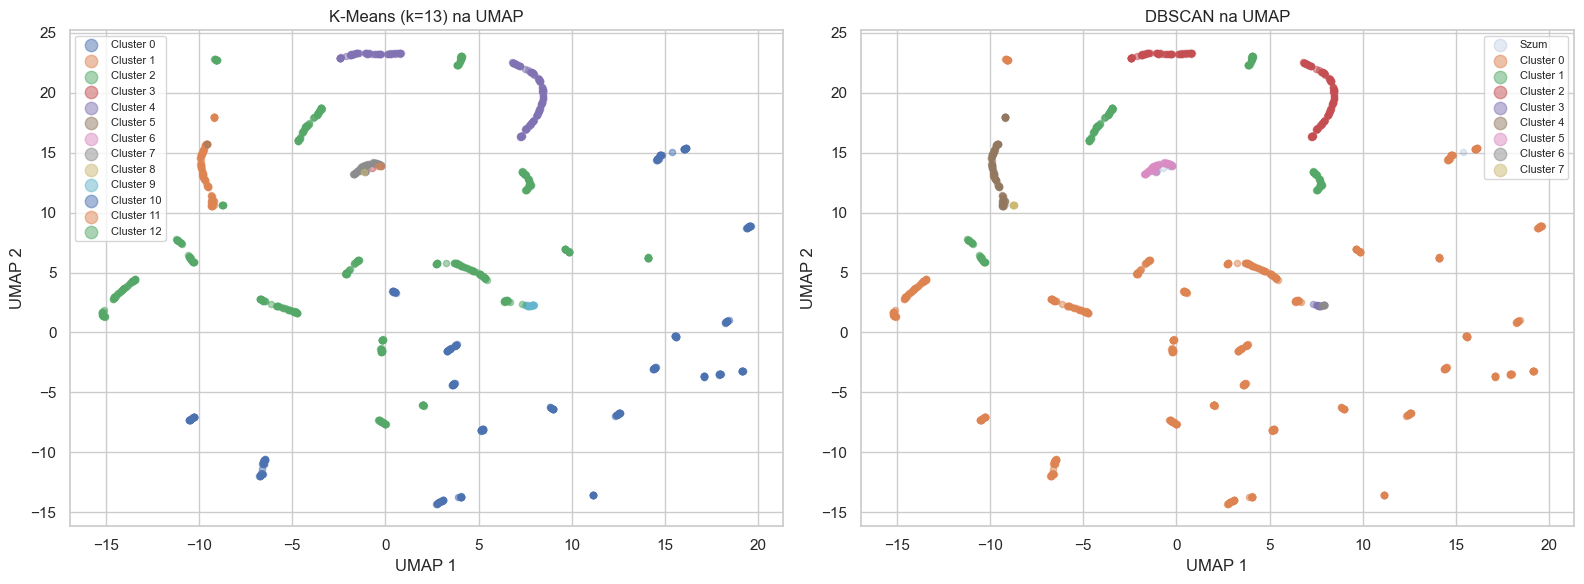


Profil klastrów (K-Means):
                n_events                n_unique_activities              duration_sec                  avg_gap_sec                n_unique_resources         \
                    mean   median count                mean median count         mean     median count        mean   median count               mean median   
kmeans_cluster                                                                                                                                                
0                  50.70     45.0   223                4.00    4.0   223        22.65      21.43   223        0.45     0.45   223               1.00    1.0   
1                1815.18   1877.0   106               22.99   23.0   106       486.03     466.28   106        0.29     0.23   106               2.00    2.0   
2                  42.00     42.0   170                7.00    7.0   170        32.27      33.48   170        0.79     0.82   170               1.00    1.0   
3               16

In [33]:
# === 5.1 Dobór optymalnego k (Elbow + Silhouette) ===
K_range = range(2, 15)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Metoda łokcia (Elbow)")

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"Najlepsze k (max silhouette): {best_k} (score={max(silhouettes):.3f})")

# === 5.2 K-Means z optymalnym k ===
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
case_stats["kmeans_cluster"] = km_best.fit_predict(X_scaled)

# === 5.3 DBSCAN ===
dbscan = DBSCAN(eps=1.5, min_samples=5)
case_stats["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = len(set(case_stats["dbscan_cluster"])) - (1 if -1 in case_stats["dbscan_cluster"].values else 0)
n_dbscan_noise = (case_stats["dbscan_cluster"] == -1).sum()
print(f"DBSCAN: {n_dbscan_clusters} klastrów, {n_dbscan_noise} punktów szumu")

# === 5.4 Wizualizacja klastrów na UMAP ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in sorted(case_stats["kmeans_cluster"].unique()):
    mask = case_stats["kmeans_cluster"] == cl
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], alpha=0.5, s=20, label=f"Cluster {cl}")
axes[0].set_title(f"K-Means (k={best_k}) na UMAP")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend(markerscale=2, fontsize=8)

for cl in sorted(case_stats["dbscan_cluster"].unique()):
    mask = case_stats["dbscan_cluster"] == cl
    label = f"Cluster {cl}" if cl != -1 else "Szum"
    alpha = 0.5 if cl != -1 else 0.15
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], alpha=alpha, s=20, label=label)
axes[1].set_title("DBSCAN na UMAP")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()

# === 5.5 Profil klastrów (K-Means) ===
profile_cols = ["n_events", "n_unique_activities", "duration_sec", "avg_gap_sec", "n_unique_resources"]
cluster_profile = case_stats.groupby("kmeans_cluster")[profile_cols].agg(["mean", "median", "count"])
print("\nProfil klastrów (K-Means):")
print(cluster_profile.round(2))

## 6. Analiza relacji między zdarzeniami

- **Macierz przejść (Directly-Follows)** – ile razy aktywność A była bezpośrednio następowana przez B
- **Top przejścia** – najczęstsze pary kolejnych aktywności
- **Czas przejścia** – rozkład czasu między kolejnymi zdarzeniami per typ przejścia

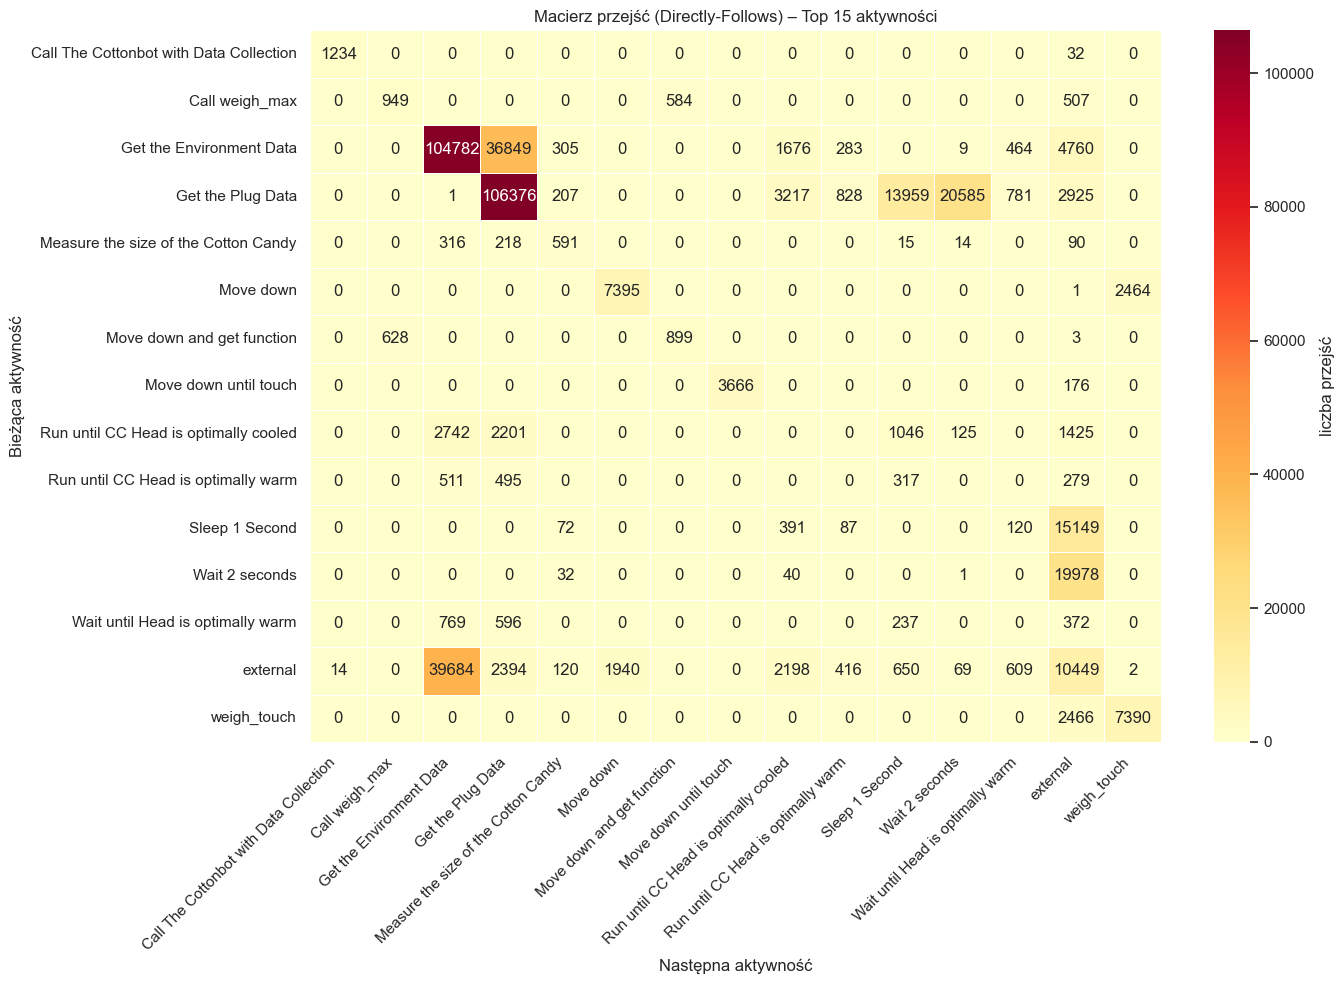

Top 20 najczęstszych przejść:
  Get the Plug Data                        → Get the Plug Data                        (106376)
  Get the Environment Data                 → Get the Environment Data                 (104782)
  external                                 → Get the Environment Data                 (39684)
  Get the Environment Data                 → Get the Plug Data                        (36849)
  Get the Plug Data                        → Wait 2 seconds                           (20585)
  Wait 2 seconds                           → external                                 (19978)
  Sleep 1 Second                           → external                                 (15149)
  Get the Plug Data                        → Sleep 1 Second                           (13959)
  external                                 → external                                 (10449)
  Move down                                → Move down                                (7395)
  weigh_touch                

/var/folders/ws/p5kx9dl15g1gyphfrcyg239w0000gn/T/ipykernel_30969/274474135.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tt_top, y="transition", x="time_to_next", orient="h", palette="Set2")


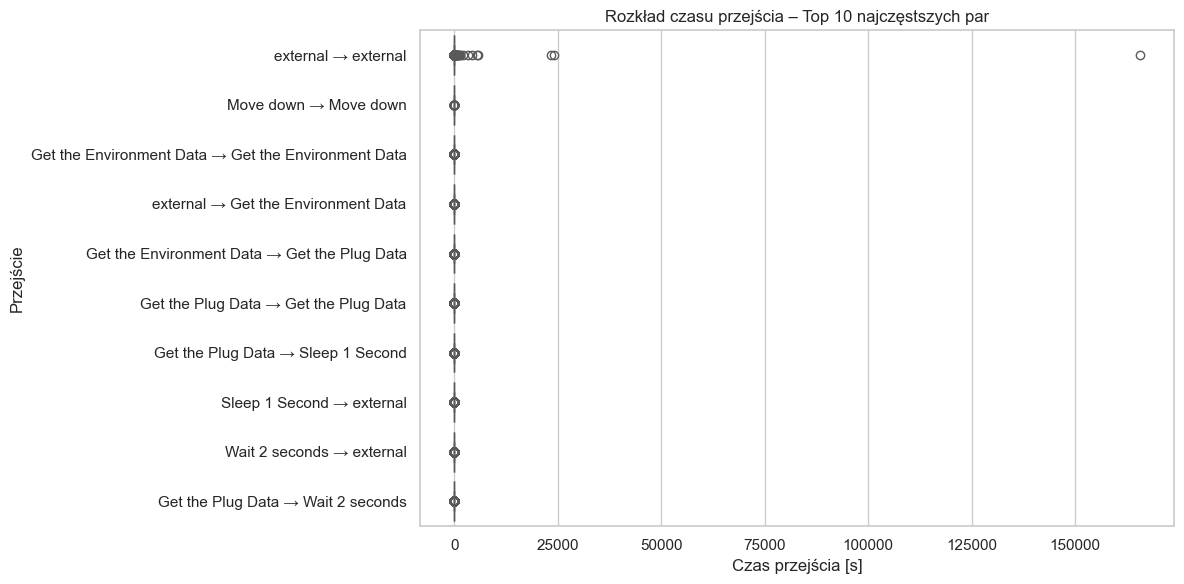

In [34]:
# === 6.1 Macierz przejść (Directly-Follows Graph) ===
df_sorted = df.sort_values(["case_id", "timestamp"]).copy()
df_sorted["next_activity"] = df_sorted.groupby("case_id")["activity_clean"].shift(-1)

# Filtrujemy tylko przejścia wewnątrz case
transitions = df_sorted.dropna(subset=["activity_clean", "next_activity"])
transition_counts = (
    transitions.groupby(["activity_clean", "next_activity"])
    .size()
    .reset_index(name="count")
)

# Top 15 aktywności do macierzy przejść (czytelna heatmapa)
top_acts = df["activity_clean"].value_counts().head(15).index.tolist()
trans_filtered = transition_counts[
    transition_counts["activity_clean"].isin(top_acts) &
    transition_counts["next_activity"].isin(top_acts)
]
trans_matrix = trans_filtered.pivot_table(
    index="activity_clean", columns="next_activity", values="count", fill_value=0
)

# pivot_table daje float; do annot z fmt='d' potrzebujemy int.
trans_matrix = trans_matrix.astype(int)

plt.figure(figsize=(14, 10))
sns.heatmap(trans_matrix, cmap="YlOrRd", linewidths=0.5,
            annot=True, fmt="d", cbar_kws={"label": "liczba przejść"})
plt.title("Macierz przejść (Directly-Follows) – Top 15 aktywności")
plt.xlabel("Następna aktywność")
plt.ylabel("Bieżąca aktywność")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === 6.2 Top 20 najczęstszych przejść ===
print("Top 20 najczęstszych przejść:")
top_trans = transition_counts.sort_values("count", ascending=False).head(20)
for _, row in top_trans.iterrows():
    print(f"  {str(row['activity_clean']):40s} → {str(row['next_activity']):40s} ({row['count']})")

# === 6.3 Czas między zdarzeniami per typ przejścia ===
df_sorted["time_to_next"] = (
    df_sorted.groupby("case_id")["timestamp"]
    .diff(-1).abs().dt.total_seconds()
)
transition_times = df_sorted.dropna(subset=["next_activity", "time_to_next"]).copy()
transition_times["transition"] = (
    transition_times["activity_clean"].astype(str) + " → " + transition_times["next_activity"].astype(str)
)

# Top 10 najczęstszych przejść – rozkład czasu
top_10_trans = transition_times["transition"].value_counts().head(10).index
tt_top = transition_times[transition_times["transition"].isin(top_10_trans)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=tt_top, y="transition", x="time_to_next", orient="h", palette="Set2")
plt.xlabel("Czas przejścia [s]")
plt.ylabel("Przejście")
plt.title("Rozkład czasu przejścia – Top 10 najczęstszych par")
plt.tight_layout()
plt.show()

## 7. Identyfikacja wzorców czasowych

Analizujemy sezonowość i regularności w danych:
- rozkład zdarzeń wg **godziny dnia** i **dnia tygodnia**
- **heatmapa** dzień tygodnia × godzina
- **timeline dzienny** – jak zmienia się aktywność procesu w czasie
- porównanie metryk per batch (ewolucja procesu)

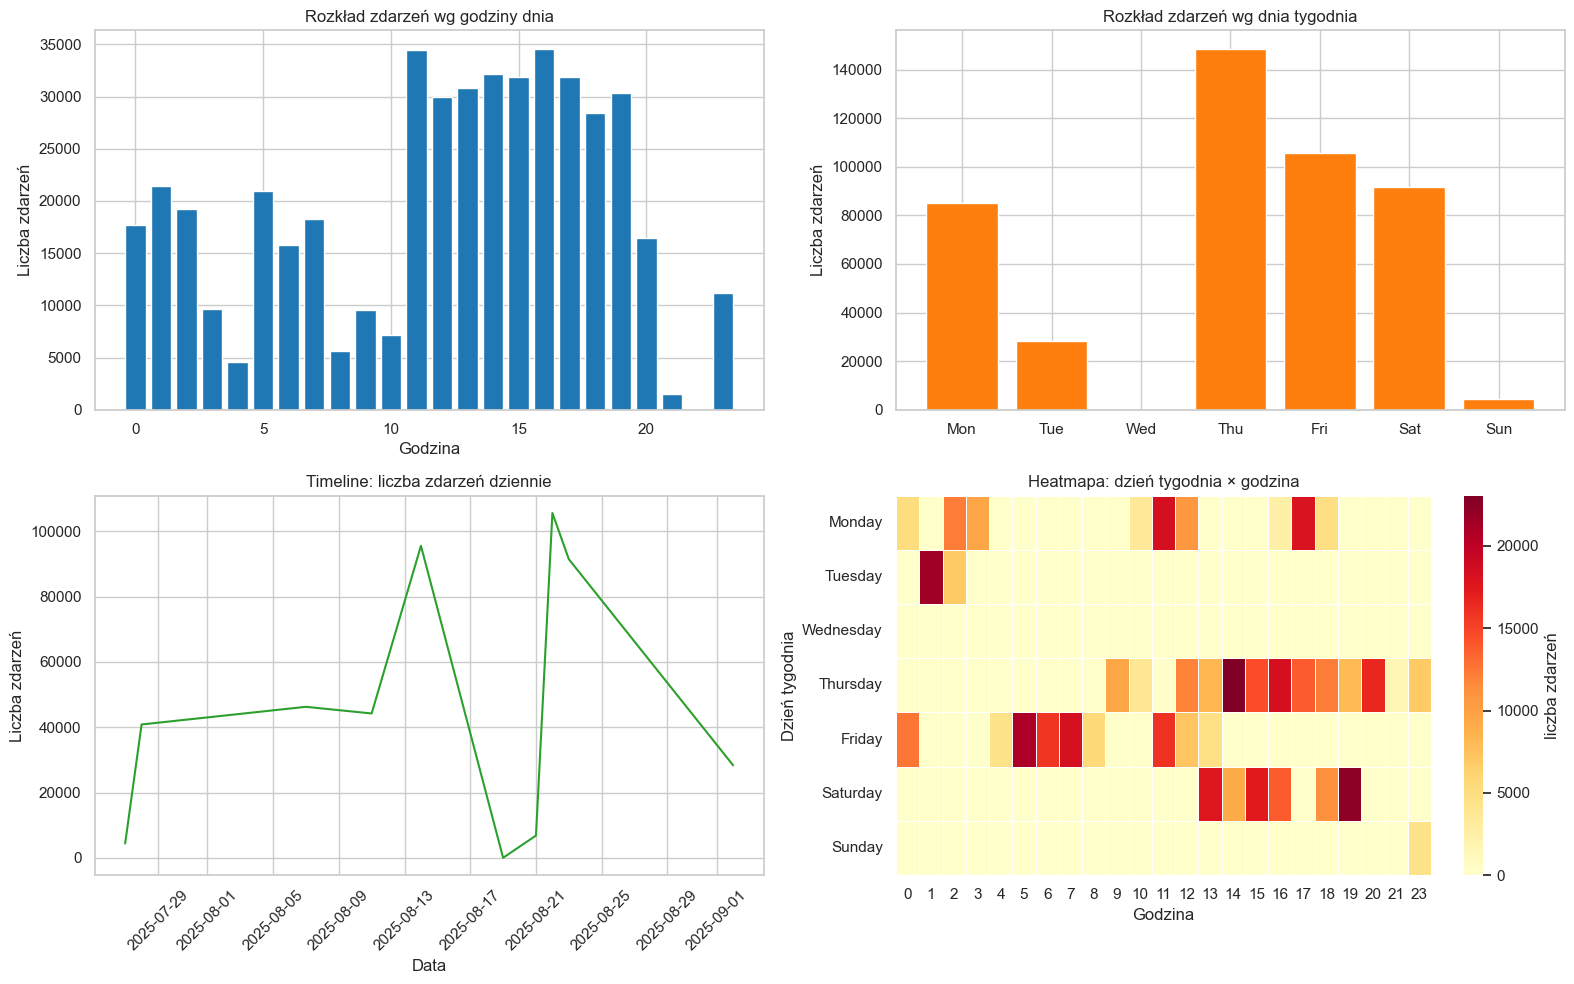

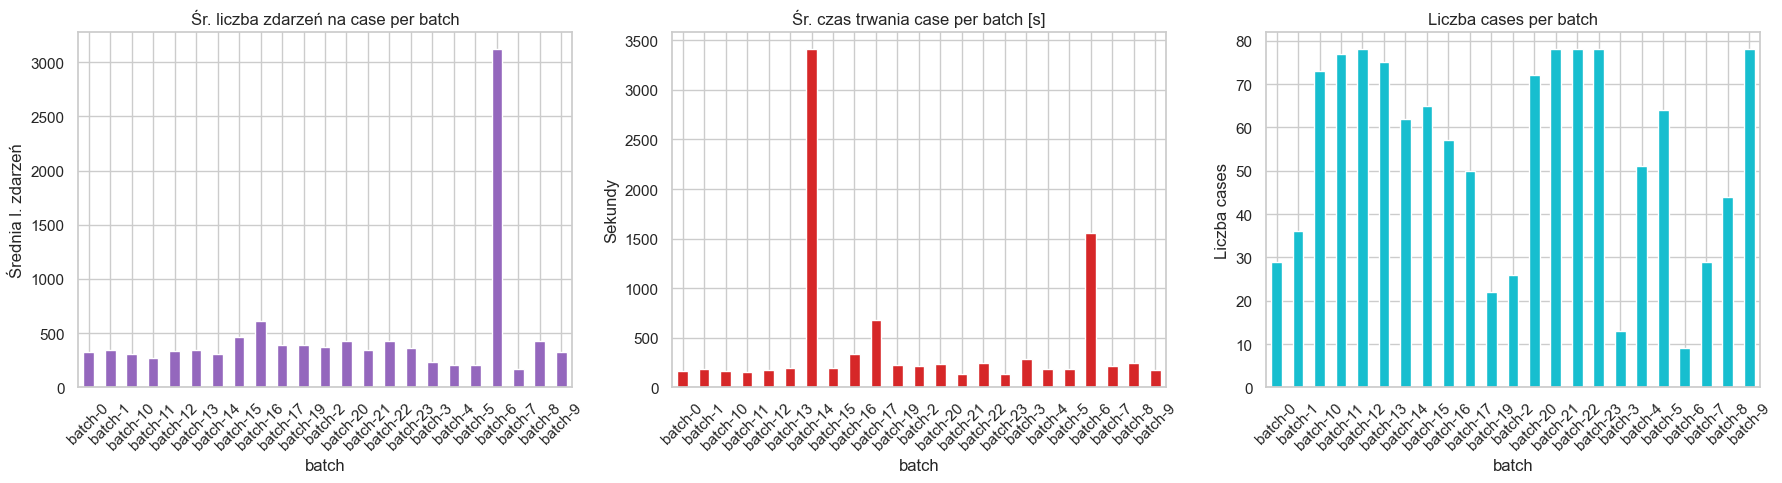

In [35]:
# === 7.1 Cechy temporalne zdarzeń ===
df["hour"] = df["timestamp"].dt.hour
df["dow"] = df["timestamp"].dt.day_name()
df["date"] = df["timestamp"].dt.date

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Godzina dnia
hourly = df["hour"].value_counts().sort_index()
axes[0, 0].bar(hourly.index, hourly.values, color="#1f77b4")
axes[0, 0].set_xlabel("Godzina")
axes[0, 0].set_ylabel("Liczba zdarzeń")
axes[0, 0].set_title("Rozkład zdarzeń wg godziny dnia")

# Dzień tygodnia
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = df["dow"].value_counts().reindex(dow_order).fillna(0)
axes[0, 1].bar(range(len(dow_order)), dow_counts.values, color="#ff7f0e")
axes[0, 1].set_xticks(range(len(dow_order)))
axes[0, 1].set_xticklabels([d[:3] for d in dow_order])
axes[0, 1].set_ylabel("Liczba zdarzeń")
axes[0, 1].set_title("Rozkład zdarzeń wg dnia tygodnia")

# Timeline dzienny
daily = df.groupby("date").size()
axes[1, 0].plot(daily.index, daily.values, color="#2ca02c")
axes[1, 0].set_xlabel("Data")
axes[1, 0].set_ylabel("Liczba zdarzeń")
axes[1, 0].set_title("Timeline: liczba zdarzeń dziennie")
axes[1, 0].tick_params(axis='x', rotation=45)

# Heatmapa: dzień tygodnia × godzina
heat_data = df.groupby(["dow", "hour"]).size().unstack(fill_value=0)
heat_data = heat_data.reindex(dow_order).fillna(0)
sns.heatmap(heat_data, cmap="YlOrRd", ax=axes[1, 1], linewidths=0.5,
            cbar_kws={"label": "liczba zdarzeń"})
axes[1, 1].set_title("Heatmapa: dzień tygodnia × godzina")
axes[1, 1].set_xlabel("Godzina")
axes[1, 1].set_ylabel("Dzień tygodnia")

plt.tight_layout()
plt.show()

# === 7.2 Ewolucja procesu w czasie (per batch) ===
batch_stats = case_stats.groupby("batch").agg(
    mean_events=("n_events", "mean"),
    mean_duration=("duration_sec", "mean"),
    n_cases=("case_id", "count"),
).sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

batch_stats["mean_events"].plot(kind="bar", ax=axes[0], color="#9467bd")
axes[0].set_title("Śr. liczba zdarzeń na case per batch")
axes[0].set_ylabel("Średnia l. zdarzeń")
axes[0].tick_params(axis='x', rotation=45)

batch_stats["mean_duration"].plot(kind="bar", ax=axes[1], color="#d62728")
axes[1].set_title("Śr. czas trwania case per batch [s]")
axes[1].set_ylabel("Sekundy")
axes[1].tick_params(axis='x', rotation=45)

batch_stats["n_cases"].plot(kind="bar", ax=axes[2], color="#17becf")
axes[2].set_title("Liczba cases per batch")
axes[2].set_ylabel("Liczba cases")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Analiza częstości ścieżek i najczęstszych wariantów

**Wariant procesu** = unikatowa sekwencja aktywności w ramach jednego case.

Analizujemy:
- ile jest unikalnych wariantów
- jakie warianty są najczęstsze
- ile wariantów potrzeba do pokrycia 80% / 95% przypadków
- rozkład długości wariantów (liczba kroków)

Liczba unikalnych wariantów: 261
Top 1 wariant obejmuje 165 cases (13.3%)

Top 15 wariantów (obejmuje 938/1244 cases):
   1. [ 165 cases] external → external → external → external → external → external → Initialize the sizes of the CC → Initialize the sizes ...
   2. [ 141 cases] external → external → external → external → external → external → Initialize Count → Initialize Count → Move down → Move...
   3. [  92 cases] external → external → external → external → external → external → Initialize the max pressure of the CC → Initialize the...
   4. [  91 cases] external → external → external → external → external → external → Initialize Vars → Initialize Vars → CUP_weight → CUP_w...
   5. [  70 cases] external → external → external → external → external → external → Initialize Vars → Initialize Vars → CUP_weight → CUP_w...
   6. [  63 cases] external → external → external → external → external → external → Initialize Count → Initialize Count → Move down → Move...
   7. [  56 cases] exte

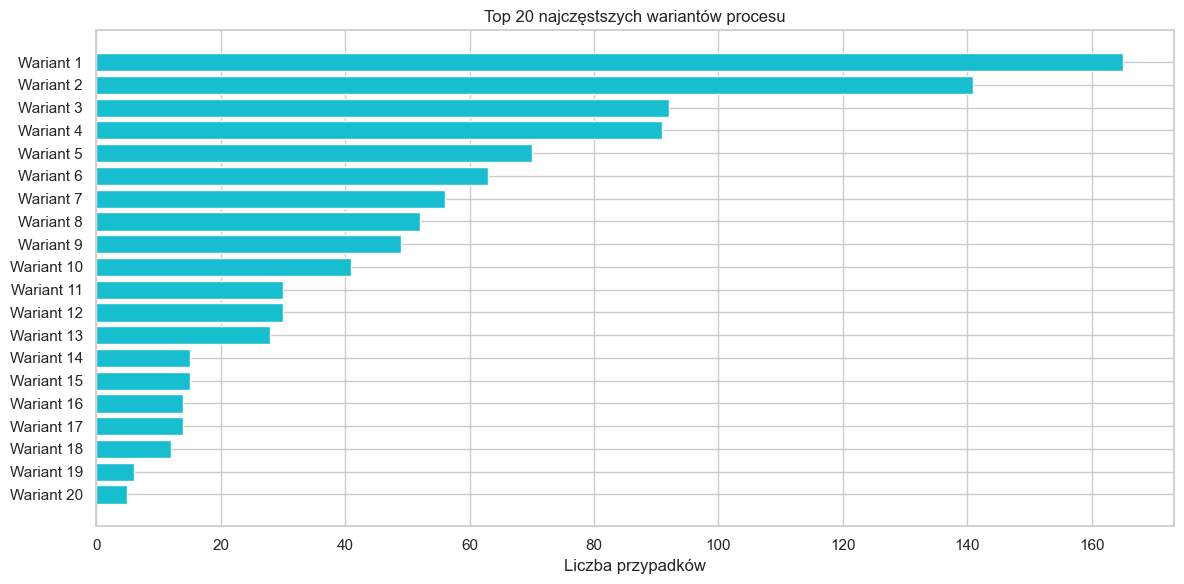


Warianty występujące 1 raz: 230 (88.1%)
Warianty występujące ≤5 razy: 242 (92.7%)
Wariantów do pokrycia 80% cases: 22
Wariantów do pokrycia 95% cases: 199


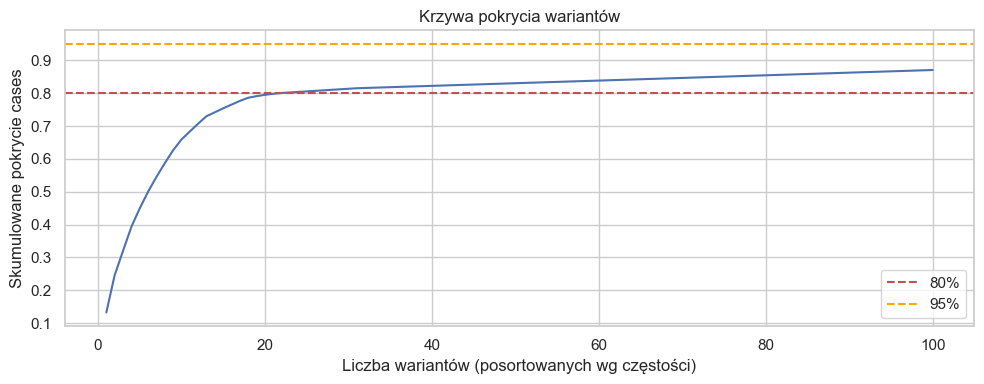

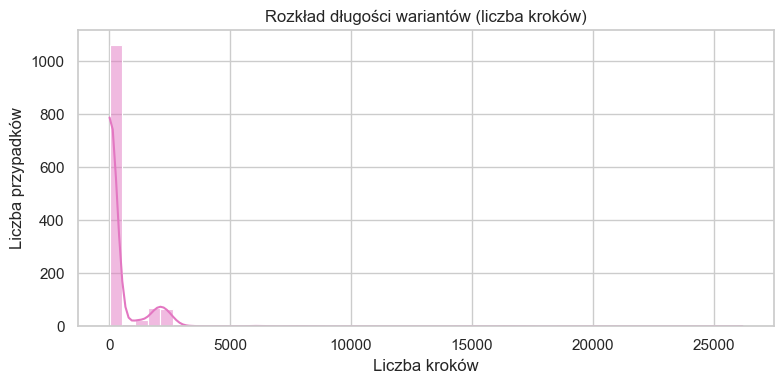

In [36]:
# === 8.1 Budowa wariantów (sekwencje aktywności per case) ===
case_variants = (
    df.sort_values(["case_id", "timestamp"])
    .groupby("case_id")["activity_clean"]
    .apply(lambda x: " → ".join(x.dropna().astype(str)))
    .rename("variant")
)

variant_counts = case_variants.value_counts()
print(f"Liczba unikalnych wariantów: {len(variant_counts)}")
print(f"Top 1 wariant obejmuje {variant_counts.iloc[0]} cases "
      f"({variant_counts.iloc[0]/len(case_variants)*100:.1f}%)")

# === 8.2 Top 15 wariantów ===
top_variants = variant_counts.head(15)
print(f"\nTop 15 wariantów (obejmuje {top_variants.sum()}/{len(case_variants)} cases):")
for i, (variant, count) in enumerate(top_variants.items(), 1):
    short = variant[:120] + "..." if len(variant) > 120 else variant
    print(f"  {i:2d}. [{count:4d} cases] {short}")

# Wizualizacja
top_n = min(20, len(variant_counts))
top_var_counts = variant_counts.head(top_n)

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), top_var_counts.values, color="#17becf")
plt.yticks(range(top_n), [f"Wariant {i+1}" for i in range(top_n)])
plt.xlabel("Liczba przypadków")
plt.title(f"Top {top_n} najczęstszych wariantów procesu")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# === 8.3 Analiza ogona rozkładu wariantów ===
n_unique_single = (variant_counts == 1).sum()
n_unique_under5 = (variant_counts <= 5).sum()
print(f"\nWarianty występujące 1 raz: {n_unique_single} ({n_unique_single/len(variant_counts)*100:.1f}%)")
print(f"Warianty występujące ≤5 razy: {n_unique_under5} ({n_unique_under5/len(variant_counts)*100:.1f}%)")

# Krzywa pokrycia kumulatywnego
cumulative = variant_counts.cumsum() / variant_counts.sum()
n_80 = int((cumulative <= 0.8).sum()) + 1
n_95 = int((cumulative <= 0.95).sum()) + 1
print(f"Wariantów do pokrycia 80% cases: {n_80}")
print(f"Wariantów do pokrycia 95% cases: {n_95}")

plt.figure(figsize=(10, 4))
x_range = min(100, len(cumulative))
plt.plot(range(1, x_range + 1), cumulative.values[:x_range], 'b-')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel("Liczba wariantów (posortowanych wg częstości)")
plt.ylabel("Skumulowane pokrycie cases")
plt.title("Krzywa pokrycia wariantów")
plt.legend()
plt.tight_layout()
plt.show()

# === 8.4 Rozkład długości wariantów ===
variant_lengths = (
    df.sort_values(["case_id", "timestamp"])
    .groupby("case_id")["activity_clean"]
    .count()
    .rename("variant_length")
)

plt.figure(figsize=(8, 4))
sns.histplot(variant_lengths, bins=50, kde=True, color="#e377c2")
plt.title("Rozkład długości wariantów (liczba kroków)")
plt.xlabel("Liczba kroków")
plt.ylabel("Liczba przypadków")
plt.tight_layout()
plt.show()

## 9. Wykrywanie anomalii

Stosujemy trzy niezależne metody wykrywania anomalii i porównujemy wyniki:
- **IQR** (z sekcji 3) – metoda statystyczna
- **Isolation Forest** (z sekcji 3) – drzewiasta metoda ensemble
- **Local Outlier Factor (LOF)** – metoda oparta na gęstości lokalnej

Anomalie konsensusowe = przypadki oznaczone przez ≥ 2 z 3 metod.

Dodatkowo identyfikujemy **rzadkie warianty** procesu jako potencjalne anomalie behawioralne.

LOF anomalie: 63 / 1244

Macierz nakładania się anomalii:
                    IQR  Isolation Forest   LOF
IQR               304.0              62.0  21.0
Isolation Forest   62.0              63.0   7.0
LOF                21.0               7.0  63.0

Anomalie konsensusowe (≥2 metody): 78 (6.3%)


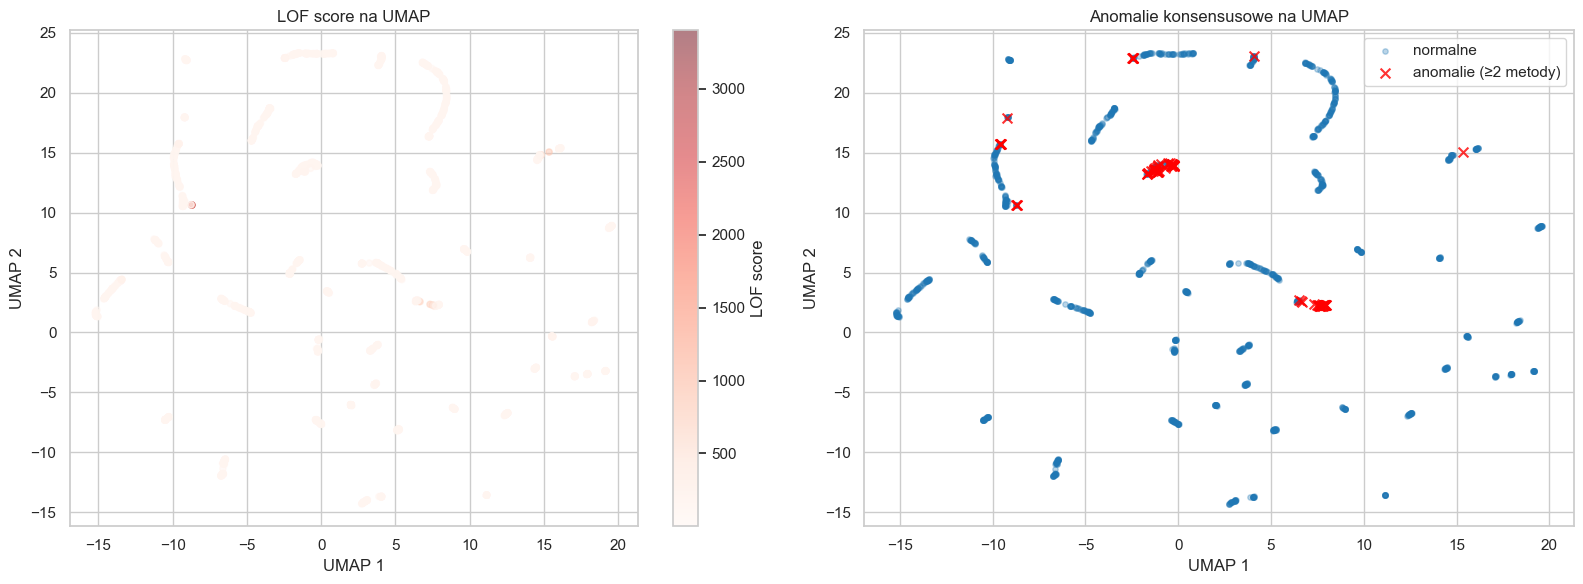


=== Profil anomalnych vs normalnych przypadków ===
         n_events                  n_unique_activities               duration_sec                   avg_gap_sec               
             mean  median      std                mean median    std         mean  median       std        mean median     std
Normalne   254.50    42.0   600.64                7.36    5.0   6.53        87.27   29.38    172.51        0.86   0.51    1.24
Anomalie  2137.85  2177.0  3582.85               18.14   23.0  11.33      4841.40  495.40  23334.20       27.87   0.24  140.66

Cases z rzadkimi wariantami (≤3 wystąpień): 251 (20.2%)
Rzadkie warianty ∩ anomalie konsensusowe: 76


In [37]:
# === 9.1 Local Outlier Factor ===
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
case_stats["lof_outlier"] = lof.fit_predict(X_scaled) == -1
lof_scores = -lof.negative_outlier_factor_
case_stats["lof_score"] = lof_scores

print(f"LOF anomalie: {case_stats['lof_outlier'].sum()} / {len(case_stats)}")

# === 9.2 Porównanie trzech metod ===
anomaly_methods = {
    "IQR": case_stats["iqr_outlier"],
    "Isolation Forest": case_stats["iso_outlier"],
    "LOF": case_stats["lof_outlier"],
}

overlap = pd.DataFrame(index=anomaly_methods.keys(), columns=anomaly_methods.keys(), dtype=int)
for m1, v1 in anomaly_methods.items():
    for m2, v2 in anomaly_methods.items():
        overlap.loc[m1, m2] = int((v1 & v2).sum())

print("\nMacierz nakładania się anomalii:")
print(overlap)

# Konsensus: ≥ 2 metody
case_stats["anomaly_consensus"] = (
    case_stats["iqr_outlier"].astype(int) +
    case_stats["iso_outlier"].astype(int) +
    case_stats["lof_outlier"].astype(int)
) >= 2

n_consensus = case_stats["anomaly_consensus"].sum()
print(f"\nAnomalie konsensusowe (≥2 metody): {n_consensus} ({n_consensus/len(case_stats)*100:.1f}%)")

# === 9.3 Wizualizacja anomalii na UMAP ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LOF score
sc = axes[0].scatter(X_umap[:, 0], X_umap[:, 1],
                     c=lof_scores, cmap="Reds", alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[0], label="LOF score")
axes[0].set_title("LOF score na UMAP")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Konsensus anomalii
normal = ~case_stats["anomaly_consensus"].values
axes[1].scatter(X_umap[normal, 0], X_umap[normal, 1],
                alpha=0.3, s=15, c="#1f77b4", label="normalne")
axes[1].scatter(X_umap[~normal, 0], X_umap[~normal, 1],
                alpha=0.8, s=50, c="red", marker="x", label="anomalie (≥2 metody)")
axes[1].set_title("Anomalie konsensusowe na UMAP")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

plt.tight_layout()
plt.show()

# === 9.4 Profil anomalnych vs normalnych ===
print("\n=== Profil anomalnych vs normalnych przypadków ===")
comparison = case_stats.groupby("anomaly_consensus")[
    ["n_events", "n_unique_activities", "duration_sec", "avg_gap_sec"]
].agg(["mean", "median", "std"])
comparison.index = ["Normalne", "Anomalie"]
print(comparison.round(2))

# === 9.5 Rzadkie warianty jako anomalie behawioralne ===
variant_freq_map = case_variants.map(variant_counts)
case_stats["variant_freq"] = variant_freq_map.reindex(case_stats["case_id"]).values

rare_threshold = 3
case_stats["rare_variant"] = case_stats["variant_freq"] <= rare_threshold
n_rare = case_stats["rare_variant"].sum()
print(f"\nCases z rzadkimi wariantami (≤{rare_threshold} wystąpień): "
      f"{n_rare} ({n_rare/len(case_stats)*100:.1f}%)")

# Czy rzadkie warianty pokrywają się z anomaliami?
rare_and_anomaly = (case_stats["rare_variant"] & case_stats["anomaly_consensus"]).sum()
print(f"Rzadkie warianty ∩ anomalie konsensusowe: {rare_and_anomaly}")

## 10. Podsumowanie Milestone 2

### Czyszczenie i normalizacja
- Sparsowano timestampy do UTC, znormalizowano endpointy do hostów, usunięto duplikaty
- Zdarzenia bez timestampa odfiltrowane jako nieanalityczne

### Outlierzy
- IQR i Isolation Forest identyfikują przypadki z ekstremalną liczbą zdarzeń lub czasem trwania
- Outlierzy to głównie procesy nadrzędne (agregujące podprocesy) lub nietypowo długie przebiegi

### Redukcja wymiarowości
- PCA pokazuje, ile komponentów wyjaśnia 90% wariancji
- t-SNE i UMAP wizualizują naturalne skupiska w danych

### Klasteryzacja
- K-Means z optymalnym k (wg Silhouette) dzieli cases na grupy o różnym profilu (krótkie podprocesy vs długie procesy główne)
- DBSCAN identyfikuje punkty szumu – potencjalne anomalie

### Relacje między zdarzeniami
- Macierz Directly-Follows pokazuje najczęstsze sekwencje aktywności
- Czasy przejść ujawniają, które kroki są najwolniejsze

### Wzorce czasowe
- Aktywność procesu skupiona w określonych godzinach/dniach tygodnia
- Widoczna ewolucja między batchami (zmiany parametrów maszyny)

### Warianty procesu
- Niewiele wariantów pokrywa większość przypadków (efekt Pareto)
- Długi ogon unikatowych wariantów sugeruje zmienność procesu

### Anomalie
- Konsensus 3 metod (IQR, IF, LOF) daje najbardziej wiarygodne anomalie
- Rzadkie warianty procesu częściowo pokrywają się z anomaliami numerycznymi